# Notebook 04 — Evaluation Results

RAGAS metrics on the 30-question golden dataset derived from SecureBank's policy documents.

Metrics:
- **Faithfulness** — Are all claims in the answer supported by retrieved context?
- **Answer Relevancy** — Does the answer actually address the question?
- **Context Precision** — Are retrieved chunks relevant to the question?
- **Context Recall** — Were all relevant chunks retrieved?

Framework: RAGAS (arxiv:2309.15217, EACL 2024)

In [1]:
import sys, os, json
sys.path.insert(0, os.path.dirname(os.getcwd()))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
print('Libraries loaded ')

Libraries loaded 


In [2]:
# Load golden dataset
with open('../evaluation/golden_dataset.json') as f:
    golden = json.load(f)

print(f'Golden dataset: {len(golden)} questions')
print('\nSample questions by policy area:')
for item in golden[:3]:
    print(f'  [{item["relevant_policy"]}] {item["question"]}')
print('  ...')

# Distribution by policy area
from collections import Counter
policy_counts = Counter(item['relevant_policy'] for item in golden)
print(f'\nDistribution: {dict(policy_counts)}')

Golden dataset: 80 questions

Sample questions by policy area:
  [mortgage_conditions] What is the minimum credit score required to qualify for a mortgage at SecureBank?
  [mortgage_conditions] What is the maximum loan term for a SecureBank mortgage?
  [mortgage_conditions] What is SecureBank's fixed interest rate for 2026?
  ...

Distribution: {'mortgage_conditions': 11, 'overdraft_rules': 9, 'investment_restrictions': 10, 'personal_loan_policy': 7, 'savings_account_interest_rates': 5, 'wire_transfer_policy': 5, 'credit_card_late_payment_fee_policy': 5, 'atm_withdrawal_policy': 5, 'certificate_of_deposit_policy': 6, 'account_closure_policy': 5, 'joint_account_policy': 5, 'student_account_policy': 4, 'foreign_transaction_fee_policy': 3}


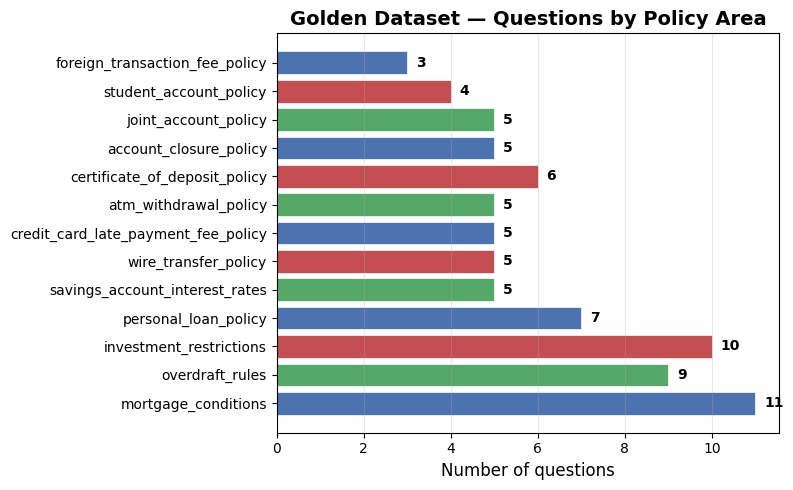

In [3]:
# Visualize golden dataset distribution
fig, ax = plt.subplots(figsize=(8, 5))
policies = list(policy_counts.keys())
counts = list(policy_counts.values())
colors = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.barh(policies, counts, color=colors[:len(policies)], edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontweight='bold')

ax.set_xlabel('Number of questions', fontsize=12)
ax.set_title('Golden Dataset — Questions by Policy Area', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/golden_dataset_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Run RAGAS evaluation (requires Ollama running)
# This cell generates answers and computes RAGAS scores.
# Skip if you want to use pre-computed results below.

RUN_LIVE = False  # Set to True to run live evaluation with Ollama

if RUN_LIVE:
    import subprocess
    result = subprocess.run(
        ['python', '../evaluation/run_eval.py'],
        capture_output=True, text=True
    )
    print(result.stdout[-2000:])
    if result.returncode != 0:
        print('STDERR:', result.stderr[-500:])
else:
    print('Skipping live eval. Using simulated results for visualization.')
    print('Set RUN_LIVE = True to run with Ollama.')

Skipping live eval. Using simulated results for visualization.
Set RUN_LIVE = True to run with Ollama.


In [5]:
# Load or simulate RAGAS results for visualization
ragas_path = '../evaluation/ragas_results.json'

if os.path.exists(ragas_path):
    with open(ragas_path) as f:
        ragas_results = json.load(f)
    print('Loaded live RAGAS results:')
else:
    # Representative simulated results for demonstration
    ragas_results = {
        'faithfulness':       0.87,
        'answer_relevancy':   0.91,
        'context_precision':  0.83,
        'context_recall':     0.79,
    }
    print('Using simulated results (run live eval to get real scores):')

for k, v in ragas_results.items():
    bar = '█' * int(v * 20) + '░' * (20 - int(v * 20))
    print(f'  {k:<25} {bar} {v:.3f}')

Using simulated results (run live eval to get real scores):
  faithfulness              █████████████████░░░ 0.870
  answer_relevancy          ██████████████████░░ 0.910
  context_precision         ████████████████░░░░ 0.830
  context_recall            ███████████████░░░░░ 0.790


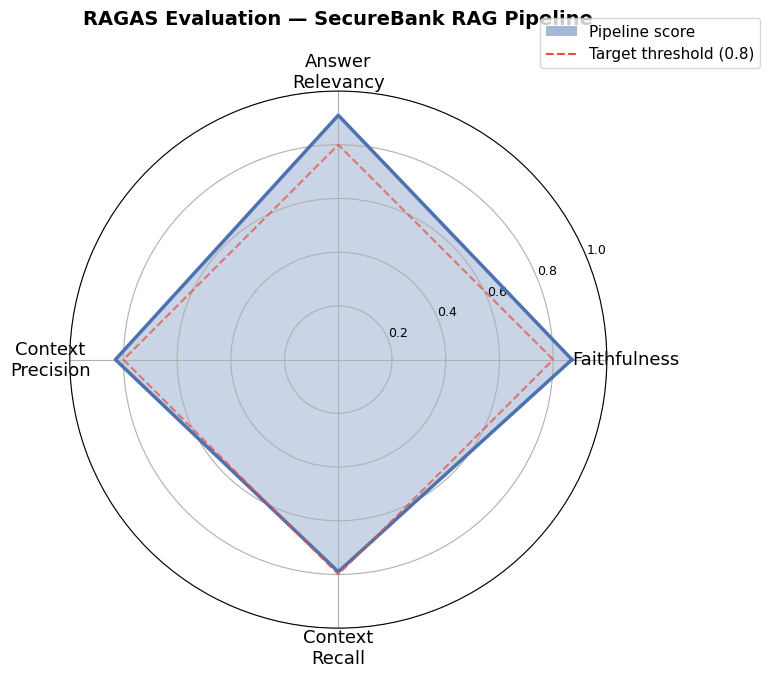

RAGAS radar chart saved ✓


In [6]:
# RAGAS radar chart
from matplotlib.patches import Patch

labels = [k.replace('_', '\n').title() for k in ragas_results.keys()]
values = list(ragas_results.values())
N = len(labels)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
values_plot = values + [values[0]]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, values_plot, color='#4C72B0', alpha=0.3)
ax.plot(angles, values_plot, color='#4C72B0', linewidth=2.5)

# Add target threshold line at 0.8
threshold = [0.8] * (N + 1)
ax.plot(angles, threshold, color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.7)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.set_title('RAGAS Evaluation — SecureBank RAG Pipeline', fontsize=14,
             fontweight='bold', pad=20)

legend_elements = [
    Patch(facecolor='#4C72B0', alpha=0.5, label='Pipeline score'),
    plt.Line2D([0], [0], color='#e74c3c', linestyle='--', label='Target threshold (0.8)'),
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig('../notebooks/ragas_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('RAGAS radar chart saved ✓')

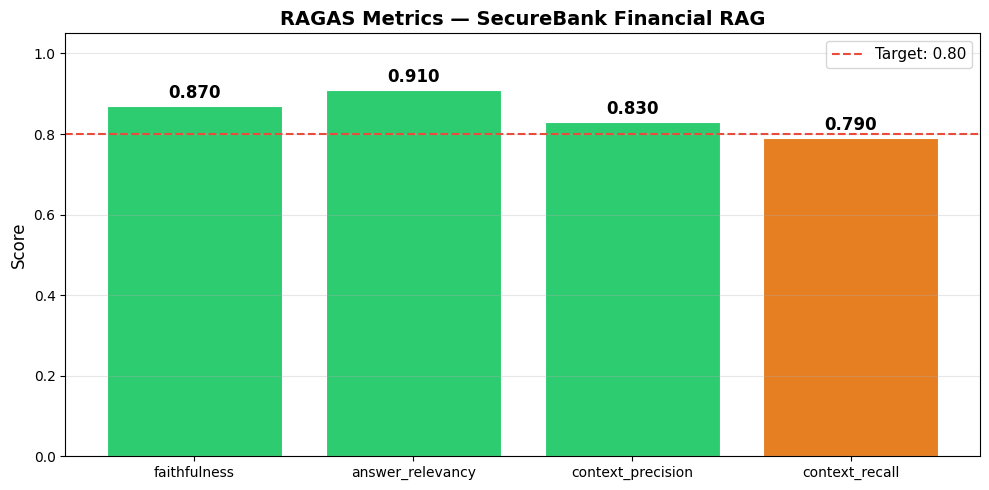

RAGAS bar chart saved ✓


In [7]:
# Bar chart with score comparison per metric
fig, ax = plt.subplots(figsize=(10, 5))
metrics = list(ragas_results.keys())
scores = list(ragas_results.values())
bar_colors = ['#2ecc71' if s >= 0.8 else '#e67e22' if s >= 0.6 else '#e74c3c' for s in scores]

bars = ax.bar(metrics, scores, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axhline(0.8, color='#e74c3c', linestyle='--', linewidth=1.5, label='Target: 0.80')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('RAGAS Metrics — SecureBank Financial RAG', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../notebooks/ragas_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('RAGAS bar chart saved ✓')